In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [17]:
df_raw = pd.read_csv("intermittent-renewables-production-france.csv")
df_raw['Date and Hour'] = df_raw['Date and Hour'].str.split('+').str[0]
df_raw['Date and Hour'] = pd.to_datetime(df_raw['Date and Hour'])
df_raw = df_raw.sort_values(by='Date and Hour').reset_index(drop=True)

In [18]:
df_solar = df_raw.loc[df_raw['Source'] == 'Solar'].reset_index(drop=True)
df_wind = df_raw.loc[df_raw['Source'] == 'Wind'].reset_index(drop=True)

In [19]:
df_solar.set_index('Date and Hour', inplace=True)
df_solar = df_solar.resample('D').sum()
df_solar['day'] = df_solar.index.day
df_solar['month'] = df_solar.index.month
df_solar['year'] = df_solar.index.year
df_solar = df_solar.dropna()

In [20]:
df_wind.set_index('Date and Hour', inplace=True)
df_wind = df_wind.resample('D').sum()
df_wind['day'] = df_wind.index.day
df_wind['month'] = df_wind.index.month
df_wind['year'] = df_wind.index.year
df_wind = df_wind.dropna()

In [21]:
features = ['year', 'month', 'day']
target = 'Production'

In [22]:
train_size_s = int(len(df_solar) * 0.8)
train_s, test_s = df_solar.iloc[:train_size_s], df_solar.iloc[train_size_s:]

In [23]:
rf_solar = RandomForestRegressor(n_estimators=100, random_state=42)
rf_solar.fit(train_s[features], train_s[target])
pred_solar = rf_solar.predict(test_s[features])

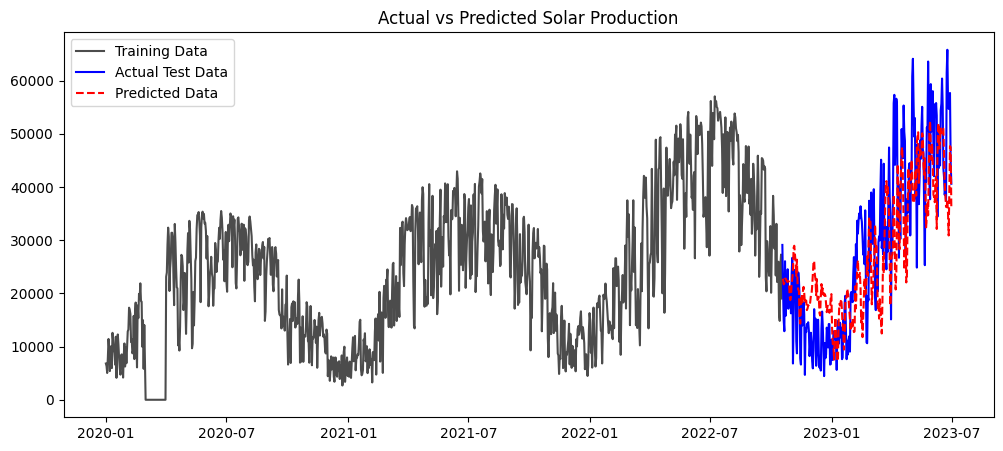

In [24]:
plt.figure(figsize=(12, 5))
plt.plot(train_s.index, train_s[target], label='Training Data', color='black', alpha=0.7)
plt.plot(test_s.index, test_s[target], label='Actual Test Data', color='blue')
plt.plot(test_s.index, pred_solar, label='Predicted Data', color='red', linestyle='--')
plt.title('Actual vs Predicted Solar Production')
plt.legend()
plt.show()

In [25]:
print(f"Solar RMSE: {np.sqrt(mean_squared_error(test_s[target], pred_solar)):.2f}")
print(f"Solar MAE: {mean_absolute_error(test_s[target], pred_solar):.2f}\n")

Solar RMSE: 11010.84
Solar MAE: 8779.46



In [26]:
train_size_w = int(len(df_wind) * 0.8)
train_w, test_w = df_wind.iloc[:train_size_w], df_wind.iloc[train_size_w:]

In [27]:
rf_wind = RandomForestRegressor(n_estimators=100, random_state=42)
rf_wind.fit(train_w[features], train_w[target])
pred_wind = rf_wind.predict(test_w[features])

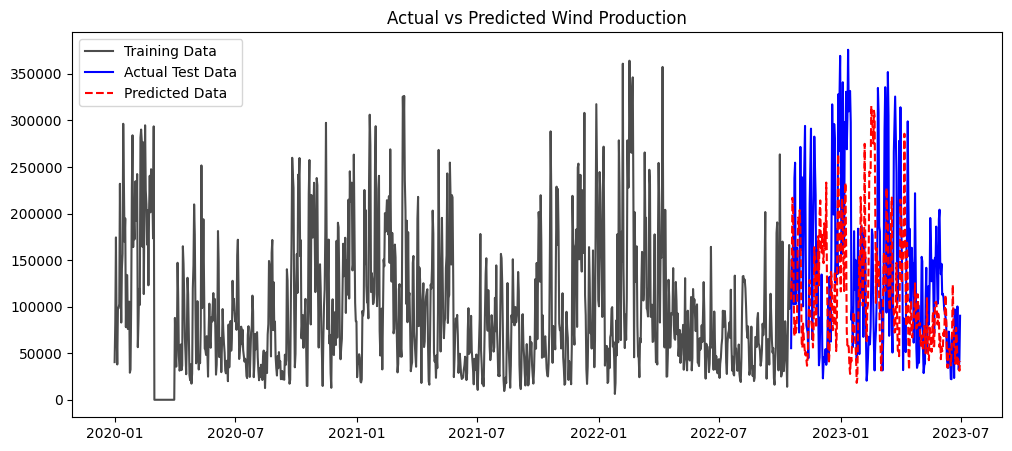

In [28]:
plt.figure(figsize=(12, 5))
plt.plot(train_w.index, train_w[target], label='Training Data', color='black', alpha=0.7)
plt.plot(test_w.index, test_w[target], label='Actual Test Data', color='blue')
plt.plot(test_w.index, pred_wind, label='Predicted Data', color='red', linestyle='--')
plt.title('Actual vs Predicted Wind Production')
plt.legend()
plt.show()


In [29]:
print(f"Wind RMSE: {np.sqrt(mean_squared_error(test_w[target], pred_wind)):.2f}")
print(f"Wind MAE: {mean_absolute_error(test_w[target], pred_wind):.2f}")

Wind RMSE: 108261.34
Wind MAE: 83586.20
